# Brillouin Spectroscopy Analysis
**Polynomial frequency calibration and Lorentzian peak fitting**

**Author:** Rutuparna Kulkarni  
**Affiliation:** Centre for BioImaging Sciences (CBIS), National University of Singapore  
**Dependencies:** Python 3.x, numpy, matplotlib, scipy, pandas

**Usage:** Set `FILE_PATTERN` below to a glob pattern (e.g. `'*.csv'`) or a single path. CSV files must have two columns: pixel index and intensity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
import pandas as pd
import glob
import warnings
warnings.filterwarnings('ignore')

## Parameters — edit here

In [ ]:
# ── File selection ─────────────────────────────────────────────────────────
# Use a glob pattern to process many files, or a single path for one file.
FILE_PATTERN = r'data/example/my_file.csv'

# ── Spectral parameters ────────────────────────────────────────────────────
FSR_GHZ        = 30.0      # Free Spectral Range in GHz
SEARCH_RANGE   = (5, 14)   # Brillouin peak search range in GHz (min, max)
USE_LORENTZIAN = True      # True = Lorentzian fit; False = peak maximum only
FIT_WINDOW     = 2.0       # Half-width of Lorentzian fit window in GHz

# ── Plot intensity axis ────────────────────────────────────────────────────
Y_MIN = 80
Y_MAX = 120

print(f'FSR = {FSR_GHZ} GHz  |  Search range = {SEARCH_RANGE[0]}-{SEARCH_RANGE[1]} GHz  |  Lorentzian: {"ON" if USE_LORENTZIAN else "OFF"}')

FSR = 30.0 GHz  |  Search range = 5-14 GHz  |  Lorentzian: ON


In [4]:
# ── CSV reader (auto-detects header) ──────────────────────────────────────
def read_spectrum(filename):
    df = pd.read_csv(filename, header=0)
    return pd.to_numeric(df.iloc[:, 1], errors='coerce').dropna().values


# ── Polynomial frequency calibration ──────────────────────────────────────
def calibrate_with_polynomial(intensity, FSR=30):
    peaks, _ = find_peaks(intensity,
                          prominence=np.max(intensity) * 0.2,
                          distance=50)
    if len(peaks) < 2:
        print('  Warning: fewer than 2 Rayleigh peaks found; using linear calibration.')
        R1 = np.argmax(intensity)
        dispersion = 10.0
        return (np.arange(len(intensity)) - R1) / dispersion, R1, dispersion, None, None

    sorted_idx = np.argsort(intensity[peaks])[::-1]
    if len(peaks) >= 3:
        R_pixels = np.sort([peaks[sorted_idx[0]], peaks[sorted_idx[1]], peaks[sorted_idx[2]]])
        R_freqs  = np.array([-FSR, 0, FSR])
    else:
        R_pixels = np.sort([peaks[sorted_idx[0]], peaks[sorted_idx[1]]])
        R_freqs  = np.array([0, FSR])

    R1_px = R_pixels[len(R_pixels) // 2]

    def poly_freq(x, a, b, R1):
        return a * (x - R1)**2 + b * (x - R1)

    try:
        popt, _ = curve_fit(poly_freq, R_pixels, R_freqs,
                            p0=[4e-5, 0.118, R1_px], maxfev=5000)
        a_cal, b_cal, R1_cal = popt
        freq = poly_freq(np.arange(len(intensity)), a_cal, b_cal, R1_cal)
        print(f'  Calibration: R1={R1_cal:.1f}px  a={a_cal:.2e}  b={b_cal:.4f}  disp={abs(b_cal):.4f} GHz/px')
        return freq, R1_cal, abs(b_cal), a_cal, b_cal
    except Exception as e:
        print(f'  Polynomial fit failed ({e}); using linear calibration.')
        R1 = R_pixels[len(R_pixels) // 2]
        dispersion = np.mean(np.diff(R_pixels)) / FSR
        return (np.arange(len(intensity)) - R1) / dispersion, R1, dispersion, None, None


# ── Lorentzian model ───────────────────────────────────────────────────────
def lorentzian(x, amplitude, center, gamma, baseline):
    return baseline + amplitude / (1 + ((x - center) / gamma)**2)


def fit_lorentzian_peak(freq, intensity, center_guess, fit_window=2.0):
    mask = (freq >= center_guess - fit_window) & (freq <= center_guess + fit_window)
    if np.sum(mask) < 5:
        return {'success': False, 'error': 'fit window too narrow'}
    xf, yf = freq[mask], intensity[mask]
    try:
        popt, pcov = curve_fit(
            lorentzian, xf, yf,
            p0=[np.max(yf) - np.min(yf), center_guess, 0.3, np.min(yf)],
            bounds=([0, center_guess - fit_window, 0.01, 0],
                    [np.inf, center_guess + fit_window, fit_window, np.inf]),
            maxfev=5000)
        perr   = np.sqrt(np.diag(pcov))
        y_pred = lorentzian(xf, *popt)
        ss_res = np.sum((yf - y_pred)**2)
        ss_tot = np.sum((yf - np.mean(yf))**2)
        r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        residual_std = np.std(yf - y_pred)
        return {
            'success': True, 'shift_GHz': popt[1],
            'shift_err_GHz': perr[1], 'FWHM_GHz': 2 * popt[2],
            'amplitude': popt[0], 'baseline': popt[3],
            'r2': r2, 'snr': popt[0] / residual_std if residual_std > 0 else 0,
            'popt': popt
        }
    except Exception as e:
        return {'success': False, 'error': str(e)}


# ── Brillouin peak finder ──────────────────────────────────────────────────
def find_and_fit_brillouin_peak(freq, intensity,
                                search_range=SEARCH_RANGE,
                                fit_window=FIT_WINDOW,
                                use_lorentzian=USE_LORENTZIAN):
    mask = (freq >= search_range[0]) & (freq <= search_range[1])
    if np.sum(mask) < 5:
        return {'success': False, 'error': 'No data in search range'}

    freq_s, int_s = freq[mask], intensity[mask]
    smooth = gaussian_filter1d(int_s, sigma=1.0)
    peaks, props = find_peaks(smooth, prominence=np.std(smooth) * 0.5, width=1)
    peak_idx     = (peaks[np.argmax(props['prominences'])] if len(peaks) > 0
                    else np.argmax(smooth))
    center_guess = freq_s[peak_idx]

    if use_lorentzian:
        result = fit_lorentzian_peak(freq, intensity, center_guess, fit_window)
        if result['success']:
            result['method'] = 'lorentzian_fit'
            return result
        print(f'  Lorentzian fit failed ({result["error"]}); using peak maximum.')

    baseline = np.percentile(int_s, 20)
    snr      = (int_s[peak_idx] - baseline) / np.std(int_s)
    return {
        'success': True, 'shift_GHz': center_guess,
        'shift_err_GHz': np.nan, 'FWHM_GHz': np.nan,
        'amplitude': int_s[peak_idx] - baseline, 'baseline': baseline,
        'r2': np.nan, 'snr': snr, 'method': 'peak_maximum'
    }

## Run Analysis

Found 9 file(s)

Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\1.3percent_Alg_Values_1.csv
  Loaded 1085 points.
  Brillouin shift : 6.8107 GHz +/- 0.0296 GHz
  Linewidth (FWHM): 0.7941 GHz
  Fit R²          : 0.8373
  SNR             : 8.0
  Method          : lorentzian_fit


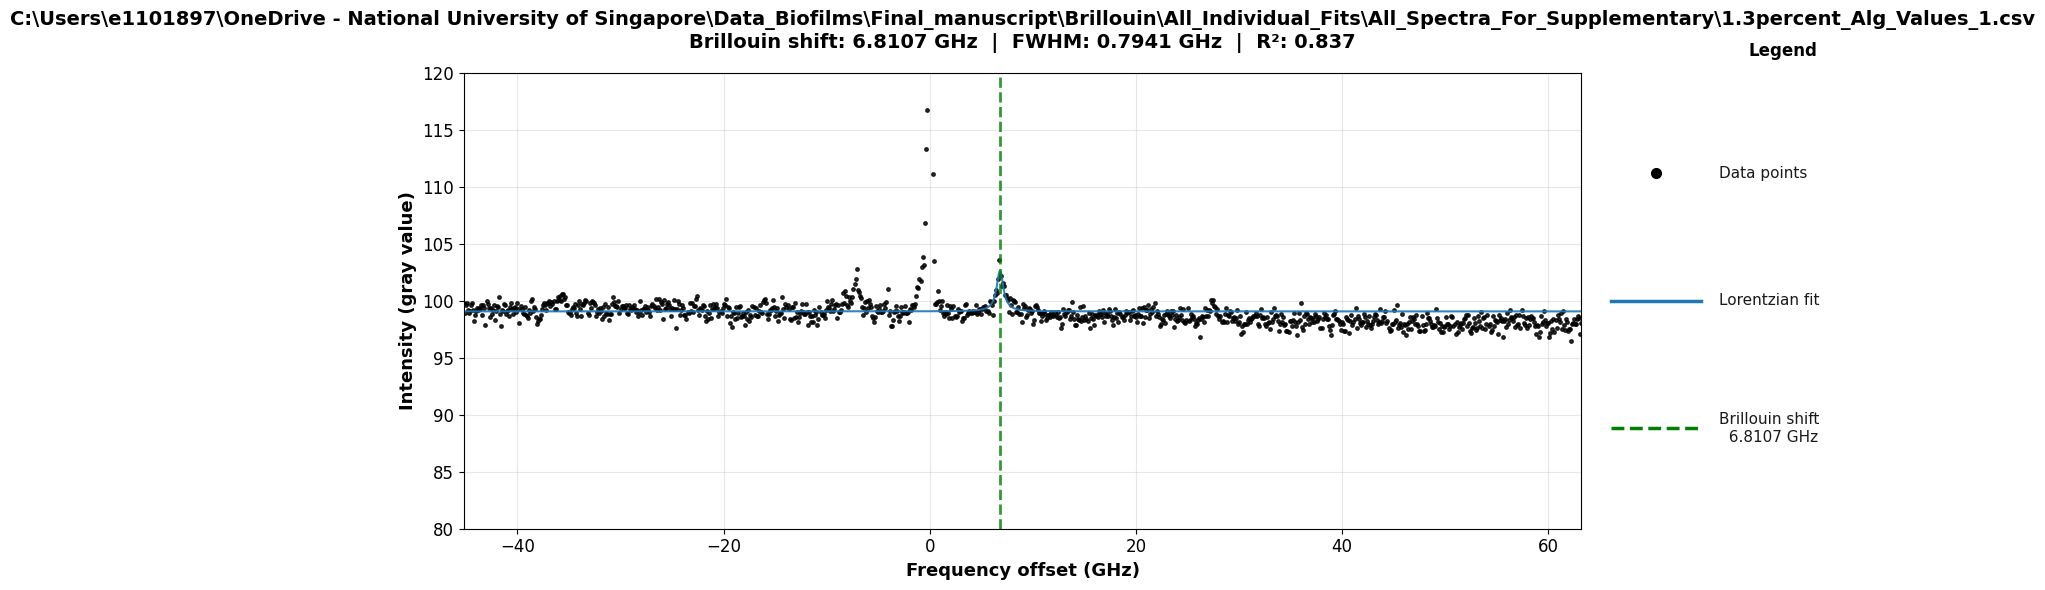

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\1.3percent_Alg_Values_1_brillouin.png
Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\2percent_Alg_Values_2.csv
  Loaded 1087 points.
  Brillouin shift : 7.1999 GHz +/- 0.0459 GHz
  Linewidth (FWHM): 0.7597 GHz
  Fit R²          : 0.6679
  SNR             : 5.0
  Method          : lorentzian_fit


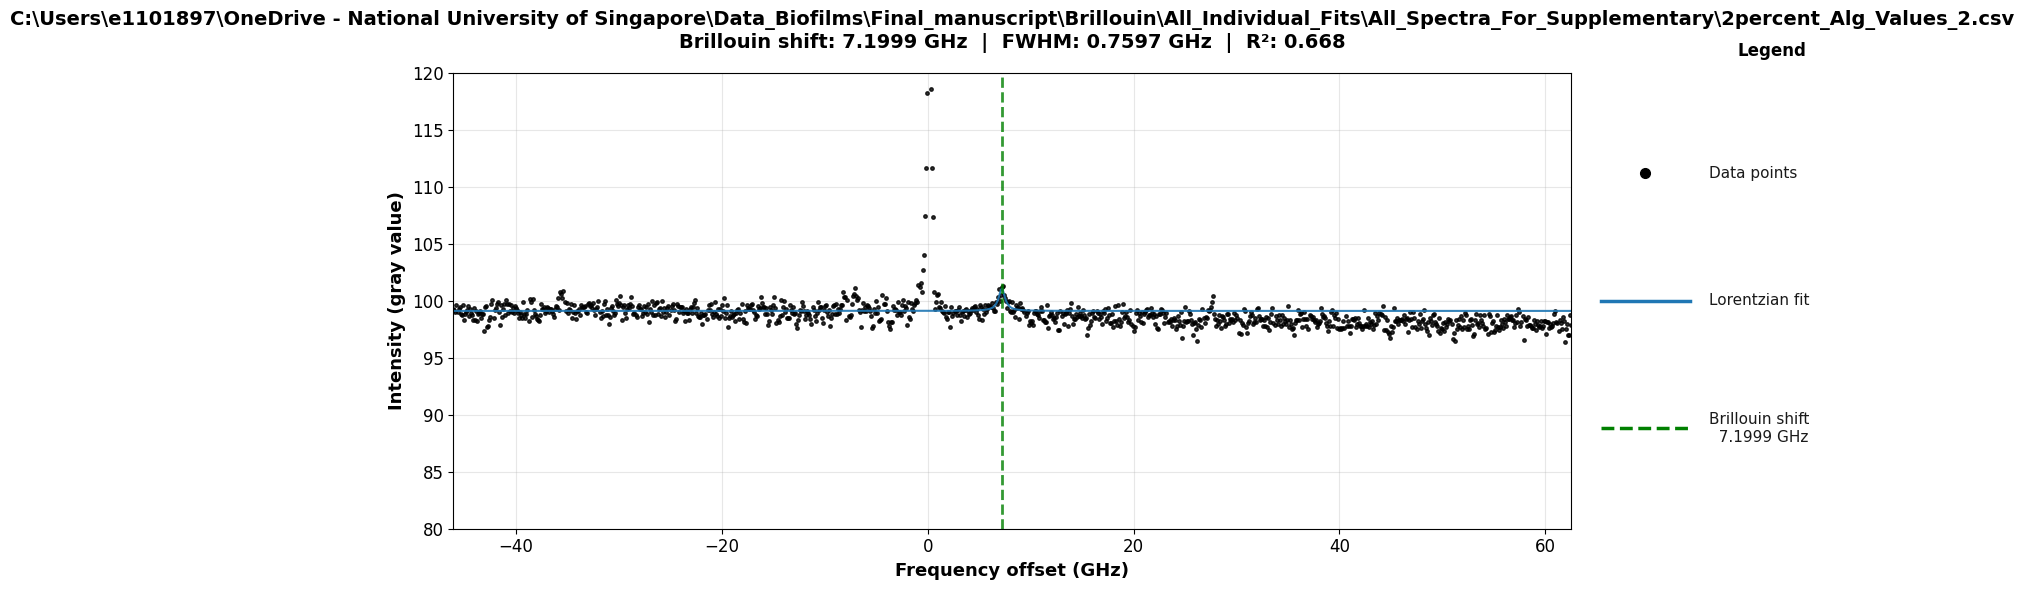

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\2percent_Alg_Values_2_brillouin.png
Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\4percent_Alg_Values.csv
  Loaded 824 points.
  Brillouin shift : 8.5292 GHz +/- 0.0501 GHz
  Linewidth (FWHM): 0.1334 GHz
  Fit R²          : 0.1347
  SNR             : 2.7
  Method          : lorentzian_fit


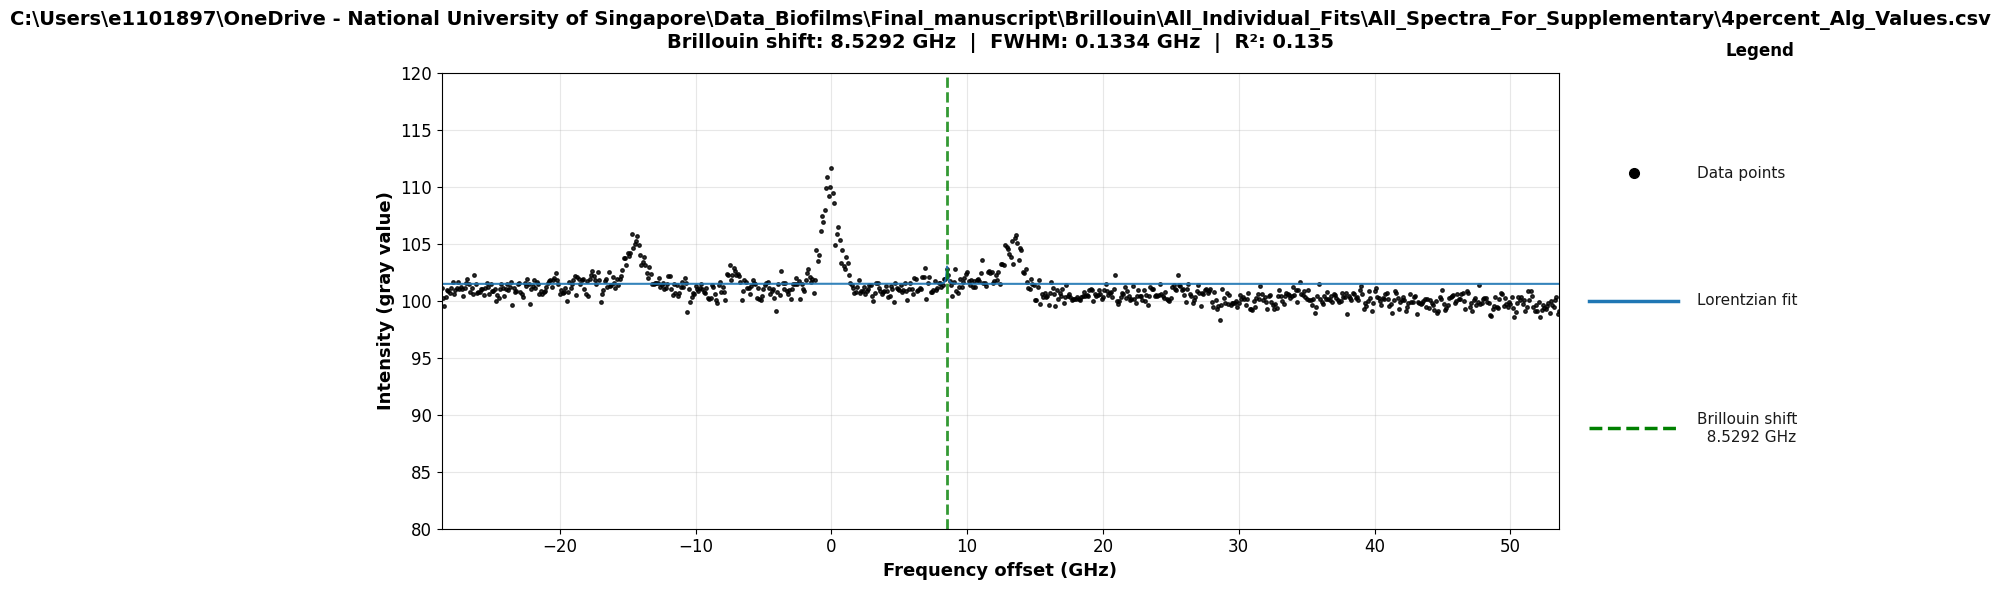

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\4percent_Alg_Values_brillouin.png
Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22302_Treated_Values_04.csv
  Loaded 824 points.
  Brillouin shift : 6.7727 GHz +/- 0.0138 GHz
  Linewidth (FWHM): 1.3005 GHz
  Fit R²          : 0.9763
  SNR             : 21.9
  Method          : lorentzian_fit


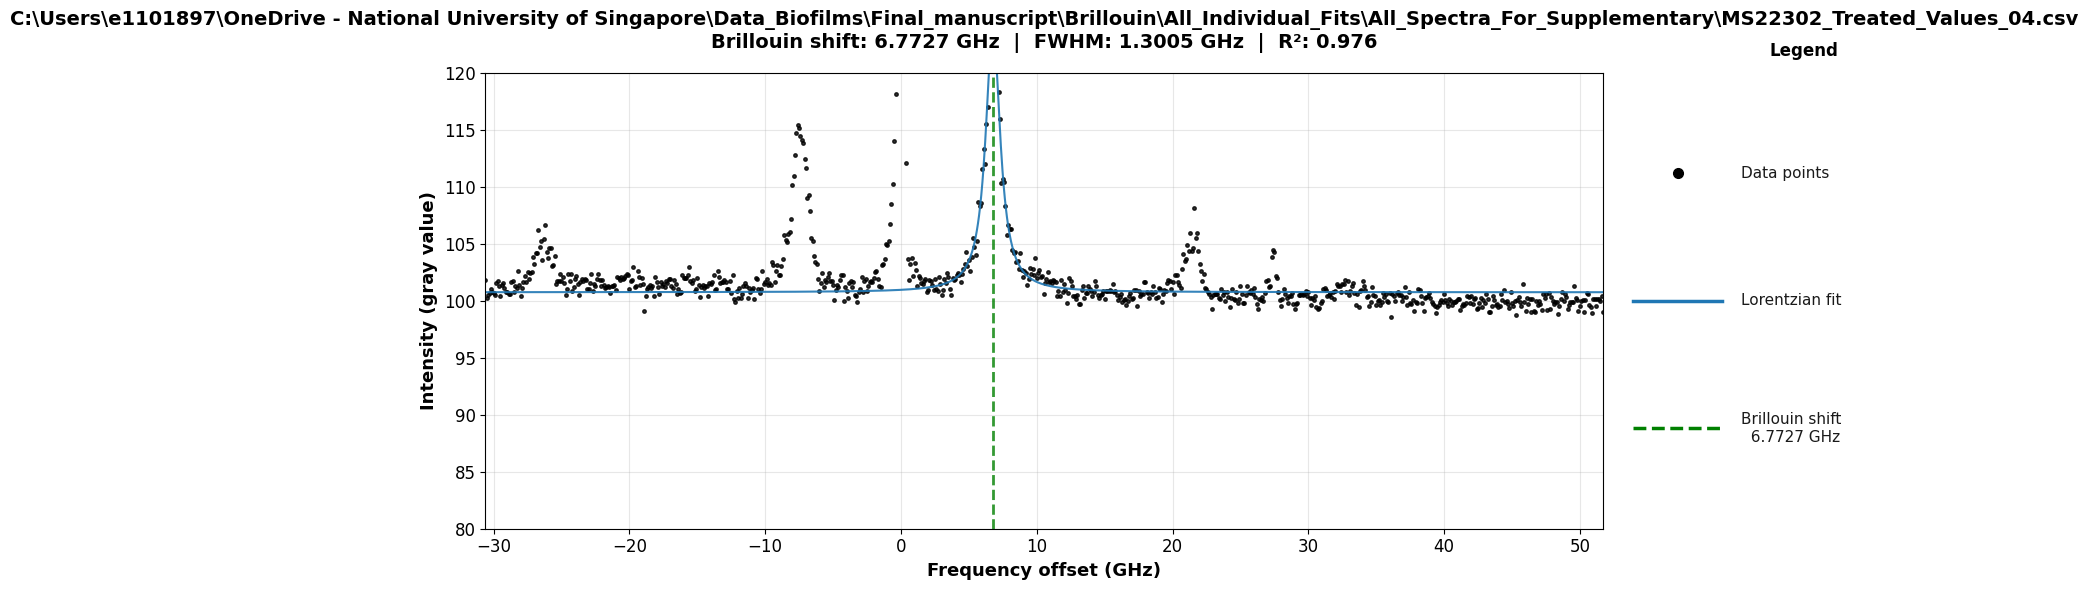

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22302_Treated_Values_04_brillouin.png
Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22302_Values_04.csv
  Loaded 824 points.
  Brillouin shift : 13.3916 GHz +/- 0.0365 GHz
  Linewidth (FWHM): 1.0666 GHz
  Fit R²          : 0.8294
  SNR             : 7.5
  Method          : lorentzian_fit


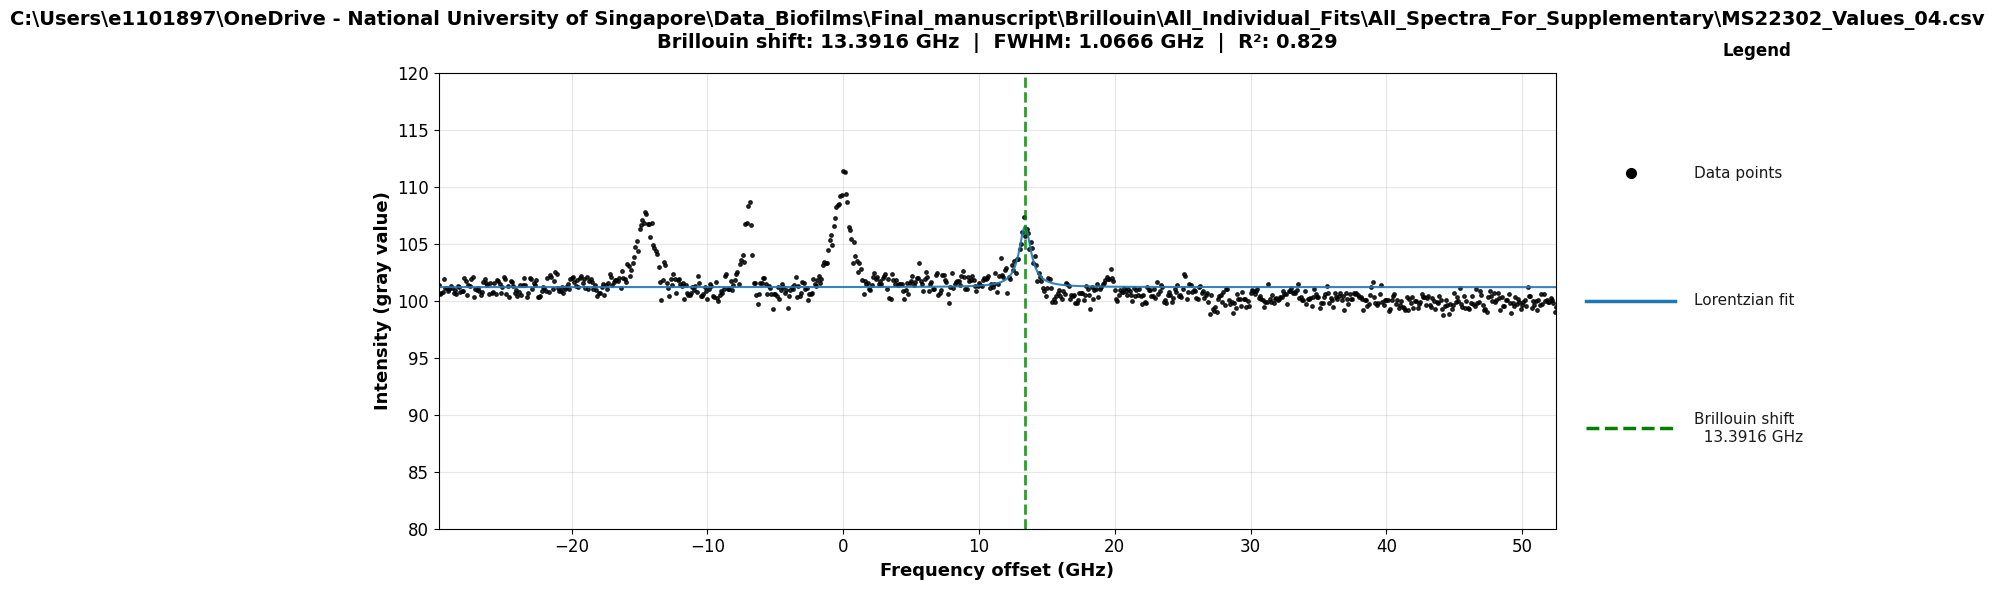

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22302_Values_04_brillouin.png
Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22302_Values_10.csv
  Loaded 848 points.
  Brillouin shift : 7.0816 GHz +/- 0.0350 GHz
  Linewidth (FWHM): 1.6851 GHz
  Fit R²          : 0.8870
  SNR             : 9.9
  Method          : lorentzian_fit


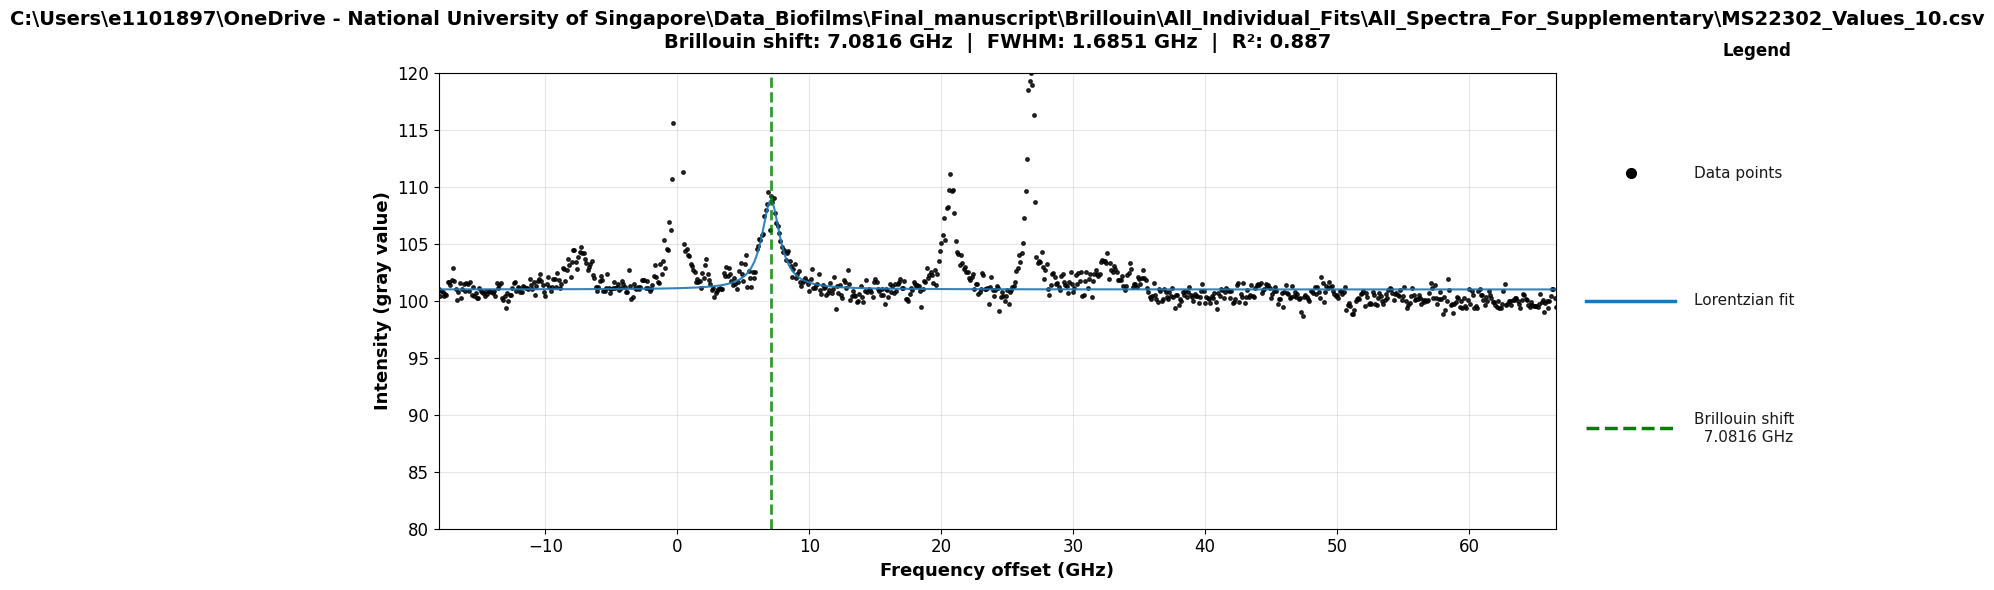

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22302_Values_10_brillouin.png
Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22303_Treated_Values_04.csv
  Loaded 824 points.
  Brillouin shift : 6.9043 GHz +/- 0.0188 GHz
  Linewidth (FWHM): 1.5841 GHz
  Fit R²          : 0.9632
  SNR             : 17.9
  Method          : lorentzian_fit


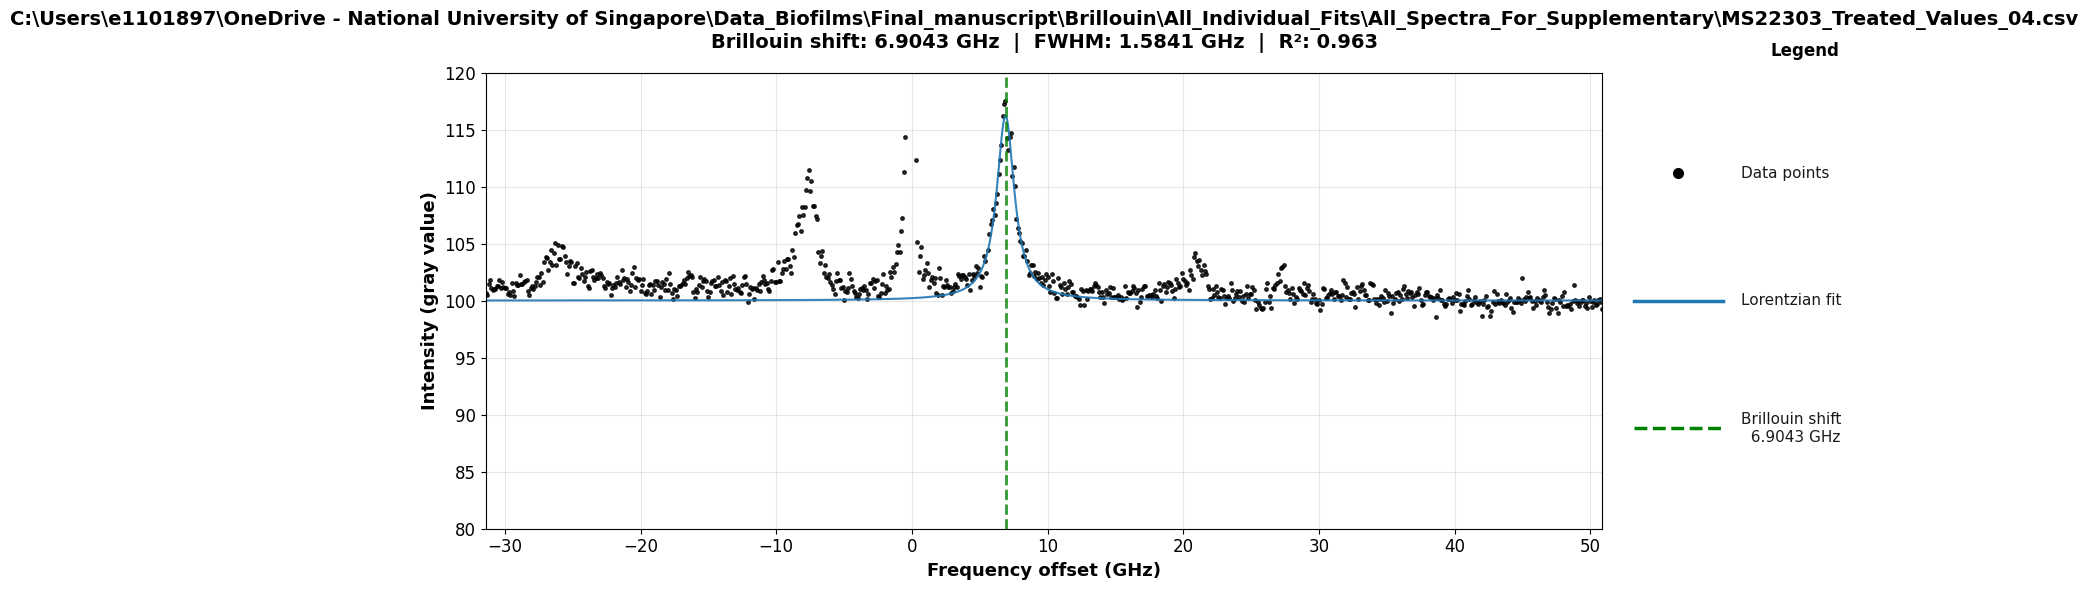

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22303_Treated_Values_04_brillouin.png
Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22303_Values_04.csv
  Loaded 848 points.
  Brillouin shift : 11.4666 GHz +/- 0.0536 GHz
  Linewidth (FWHM): 1.0168 GHz
  Fit R²          : 0.6811
  SNR             : 5.0
  Method          : lorentzian_fit


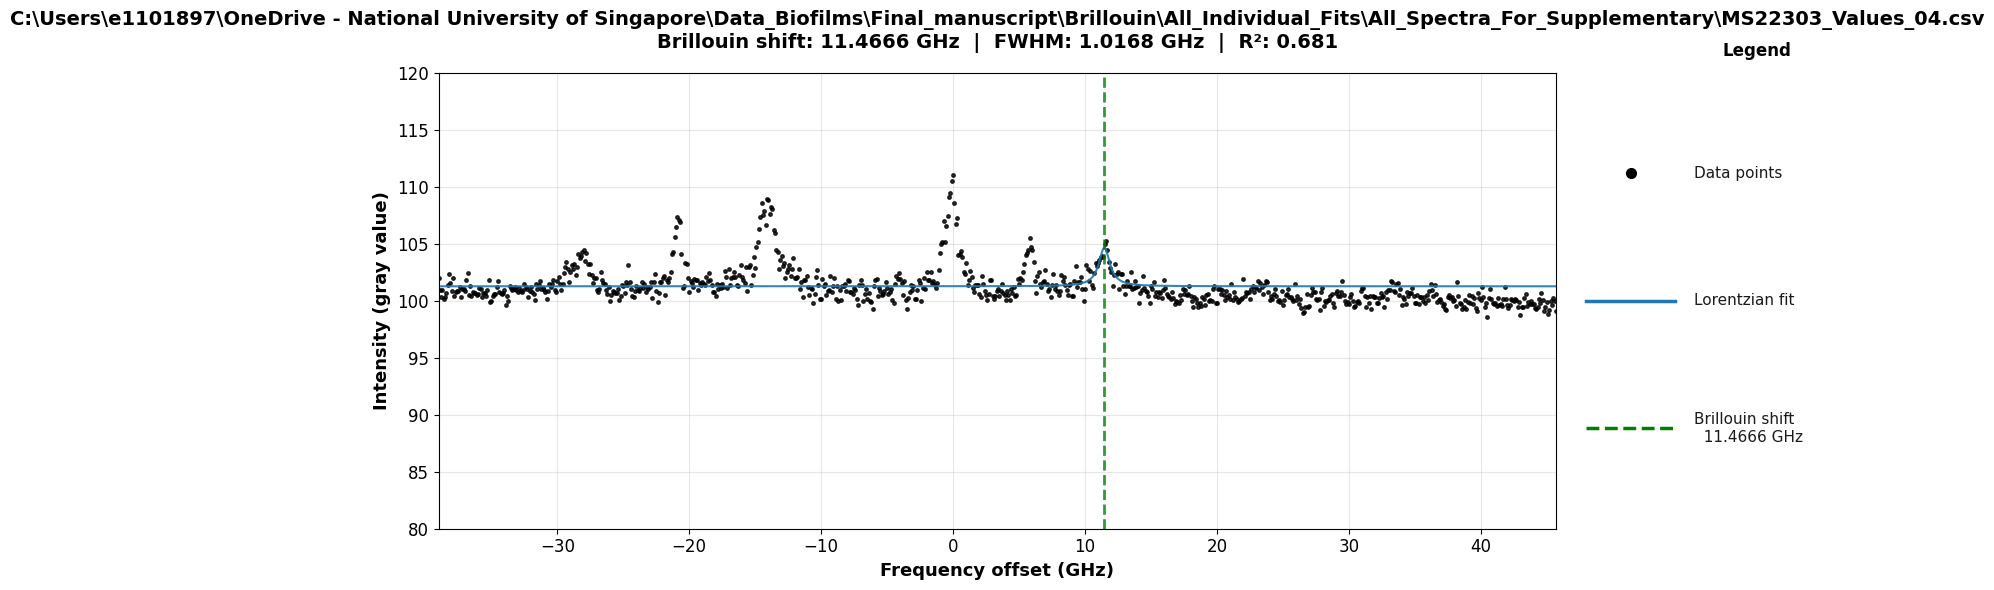

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\MS22303_Values_04_brillouin.png
Analyzing: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\PBS_Buffer_Values.csv
  Loaded 1108 points.
  Brillouin shift : 5.7624 GHz +/- 0.0246 GHz
  Linewidth (FWHM): 0.4017 GHz
  Fit R²          : 0.7240
  SNR             : 6.8
  Method          : lorentzian_fit


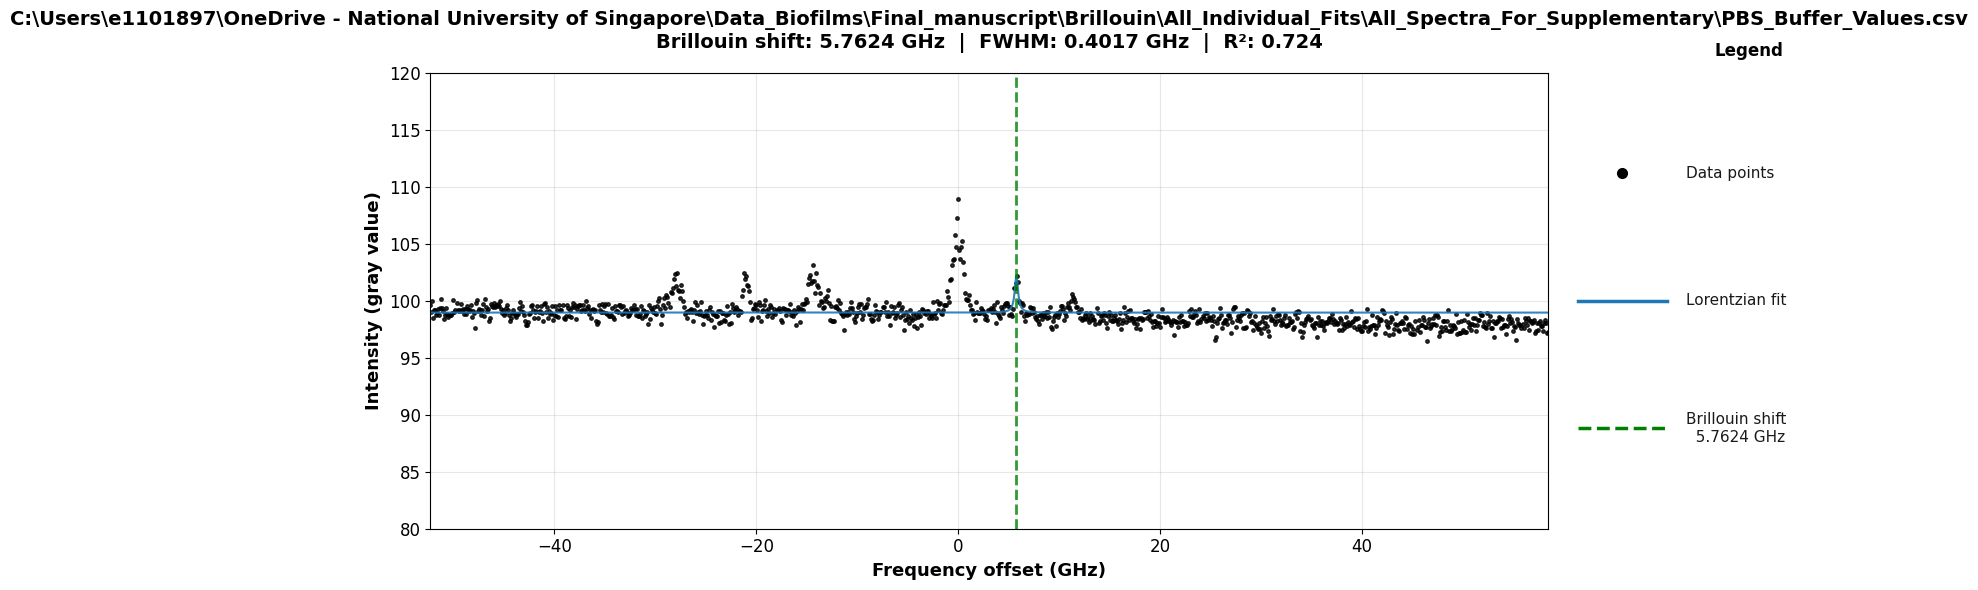

  Figure saved: C:\Users\e1101897\OneDrive - National University of Singapore\Data_Biofilms\Final_manuscript\Brillouin\All_Individual_Fits\All_Spectra_For_Supplementary\PBS_Buffer_Values_brillouin.png


In [5]:
file_list = sorted(glob.glob(FILE_PATTERN))
if not file_list:
    raise FileNotFoundError(f'No CSV files found matching: {FILE_PATTERN}')
print(f'Found {len(file_list)} file(s)\n')

results = []

for filename in file_list:
    print(f"{'='*70}\nAnalyzing: {filename}\n{'='*70}")

    intensity = read_spectrum(filename)
    print(f'  Loaded {len(intensity)} points.')

    freq, R1, dispersion, a_cal, b_cal = calibrate_with_polynomial(intensity, FSR=FSR_GHZ)
    brillouin = find_and_fit_brillouin_peak(freq, intensity)

    if brillouin['success']:
        shift_str = f"{brillouin['shift_GHz']:.4f} GHz"
        if not np.isnan(brillouin['shift_err_GHz']):
            shift_str += f" +/- {brillouin['shift_err_GHz']:.4f} GHz"
        print(f"  Brillouin shift : {shift_str}")
        if not np.isnan(brillouin['FWHM_GHz']):
            print(f"  Linewidth (FWHM): {brillouin['FWHM_GHz']:.4f} GHz")
        if not np.isnan(brillouin['r2']):
            print(f"  Fit R\u00b2          : {brillouin['r2']:.4f}")
        print(f"  SNR             : {brillouin['snr']:.1f}")
        print(f"  Method          : {brillouin['method']}")
    else:
        print(f"  Detection FAILED: {brillouin.get('error')}")

    results.append({
        'filename':              filename,
        'R1_main_rayleigh_px':   R1,
        'dispersion_GHz_per_px': dispersion,
        'poly_a':                a_cal if a_cal is not None else np.nan,
        'poly_b':                b_cal if b_cal is not None else np.nan,
        'brillouin_shift_GHz':   brillouin.get('shift_GHz', np.nan),
        'shift_uncertainty_GHz': brillouin.get('shift_err_GHz', np.nan),
        'FWHM_GHz':              brillouin.get('FWHM_GHz', np.nan),
        'fit_R2':                brillouin.get('r2', np.nan),
        'amplitude':             brillouin.get('amplitude', np.nan),
        'baseline':              brillouin.get('baseline', np.nan),
        'SNR':                   brillouin.get('snr', np.nan),
        'method':                brillouin.get('method', 'failed'),
        'success':               brillouin['success']
    })

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                   gridspec_kw={'width_ratios': [3, 1]})
    fig.subplots_adjust(top=0.82)
    freq_min, freq_max = np.min(freq), np.max(freq)

    ax1.plot(freq, intensity, 'k.', markersize=5, alpha=0.8)
    if brillouin['success'] and 'popt' in brillouin:
        freq_fine = np.linspace(freq_min, freq_max, 2000)
        ax1.plot(freq_fine, lorentzian(freq_fine, *brillouin['popt']),
                 '-', color='#1f77b4', lw=1.5, alpha=0.9)
        ax1.axvline(brillouin['shift_GHz'], color='green', ls='--', lw=2, alpha=0.8)
        title = f"{filename}\nBrillouin shift: {brillouin['shift_GHz']:.4f} GHz"
        if not np.isnan(brillouin['FWHM_GHz']):
            title += f"  |  FWHM: {brillouin['FWHM_GHz']:.4f} GHz"
        if not np.isnan(brillouin['r2']):
            title += f"  |  R\u00b2: {brillouin['r2']:.3f}"
        ax1.set_title(title, fontsize=14, fontweight='bold', pad=18)
    else:
        ax1.set_title(f"{filename}\nDetection failed", fontsize=14,
                      color='red', fontweight='bold', pad=18)

    ax1.set_xlabel('Frequency offset (GHz)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Intensity (gray value)',  fontsize=13, fontweight='bold')
    ax1.set_xlim(freq_min, freq_max)
    ax1.set_ylim(Y_MIN, Y_MAX)
    ax1.grid(alpha=0.3)
    ax1.tick_params(axis='both', labelsize=12)

    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis('off')
    ax2.set_title('Legend', fontsize=12, fontweight='bold', pad=12)
    legend_entries = [
        ('dot',  'black',    None,  'Data points'),
        ('line', '#1f77b4', '-',   'Lorentzian fit'),
    ]
    if brillouin['success']:
        legend_entries.append(
            ('line', 'green', '--', f"Brillouin shift\n  {brillouin['shift_GHz']:.4f} GHz"))
    for y, (kind, color, ls, label) in zip(
            np.linspace(0.78, 0.22, len(legend_entries)), legend_entries):
        if kind == 'dot':
            ax2.plot([0.16], [y], '.', color=color, markersize=14)
        else:
            ax2.plot([0.04, 0.28], [y, y], color=color, ls=ls, lw=2.5)
        ax2.text(0.33, y, label, va='center', ha='left', fontsize=11, color='#1a1a1a')

    plt.tight_layout()
    out_fig = filename.replace('.csv', '_brillouin.png')
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Figure saved: {out_fig}')

## Summary & Export

In [ ]:
results_df = pd.DataFrame(results)
print('\n' + '='*80 + '\nSUMMARY\n' + '='*80)
print(results_df.round(4).to_string(index=False))

output_csv = 'brillouin_results_final.csv'
results_df.to_csv(output_csv, index=False)
print(f'\nResults saved to: {output_csv}')